# Parameter Sweep Visualization for the Adaptive-Network SIR Model

This notebook explores how the three model parameters, \(\beta\), \(\gamma\), and \(\rho\), change the epidemic trajectory over time.

For each parameter set, the notebook runs repeated stochastic simulations, computes the mean infected fraction over time, and shows the full range across replicates as a shaded band.

The goal is to understand which summary statistics are informative for ABC and why the infected time series alone may not fully separate the parameters.

## 1. Import Required Libraries

We use NumPy for simulation handling, Pandas for tabular summaries, and Matplotlib for the plots. The simulator itself is imported from `simulator.py`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulator import simulate

plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
# Reproducibility and base simulator settings
seed = 20260411
base_rng = np.random.default_rng(seed)

N = 200
p_edge = 0.05
n_infected0 = 5
T = 200
n_reps = 25

# Baseline parameter values used when varying one parameter at a time.
base_beta = 0.20
base_gamma = 0.10
base_rho = 0.30

# Parameter grids for one-at-a-time sweeps.
beta_values = [0.08, 0.16, 0.24, 0.32, 0.40]
gamma_values = [0.03, 0.07, 0.11, 0.15, 0.19]
rho_values = [0.00, 0.20, 0.40, 0.60, 0.80]

print("Simulation settings:")
print(f"N={N}, p_edge={p_edge}, n_infected0={n_infected0}, T={T}, n_reps={n_reps}")


Simulation settings:
N=200, p_edge=0.05, n_infected0=5, T=200, n_reps=25


## 2. Define the Simulation and Parameter Sets

We vary one parameter at a time while keeping the other two fixed at baseline values. This makes it easier to see which part of the epidemic trajectory each parameter influences.

In [3]:
def run_replicates(beta, gamma, rho, n_reps=n_reps, N=N, p_edge=p_edge, n_infected0=n_infected0, T=T, seed=seed):
    """Run repeated simulations and collect infected-fraction curves."""
    rng = np.random.default_rng(seed)
    curves = []

    for _ in range(n_reps):
        infected_fraction, _, _ = simulate(
            beta=beta,
            gamma=gamma,
            rho=rho,
            N=N,
            p_edge=p_edge,
            n_infected0=n_infected0,
            T=T,
            rng=rng,
        )
        curves.append(infected_fraction)

    return np.asarray(curves)


def summarize_curves(curves):
    """Compute mean and range statistics over replicates for each time step."""
    summary = pd.DataFrame(
        {
            "time": np.arange(curves.shape[1]),
            "mean": curves.mean(axis=0),
            "min": curves.min(axis=0),
            "max": curves.max(axis=0),
            "p10": np.quantile(curves, 0.10, axis=0),
            "p90": np.quantile(curves, 0.90, axis=0),
        }
    )
    return summary


parameter_sweeps = {
    "beta": [{"beta": value, "gamma": base_gamma, "rho": base_rho} for value in beta_values],
    "gamma": [{"beta": base_beta, "gamma": value, "rho": base_rho} for value in gamma_values],
    "rho": [{"beta": base_beta, "gamma": base_gamma, "rho": value} for value in rho_values],
}

print("Defined parameter sweeps for beta, gamma, and rho.")

Defined parameter sweeps for beta, gamma, and rho.


## 3. Run Repeated Simulations for Each Parameter Combination

Each sweep runs the simulator multiple times at fixed parameters to capture stochastic variability in the infected fraction over time.

In [4]:
results = {}

for param_name, sweep in parameter_sweeps.items():
    sweep_results = []
    for params in sweep:
        curves = run_replicates(**params)
        summary = summarize_curves(curves)
        summary["beta"] = params["beta"]
        summary["gamma"] = params["gamma"]
        summary["rho"] = params["rho"]
        summary["param_name"] = param_name
        sweep_results.append(summary)
    results[param_name] = sweep_results

print("Completed all simulation sweeps.")

Completed all simulation sweeps.


## 4. Aggregate Infection Fraction by Time Step

For each parameter value, we compute the mean curve and a range band across repeated simulations. The shaded region shows the full minimum-to-maximum envelope across replicates, which highlights stochastic variability.

In [5]:
aggregated = {}

for param_name, sweep_results in results.items():
    aggregated[param_name] = pd.concat(sweep_results, ignore_index=True)

aggregated["beta"].head()

,time,mean,min,max,p10,p90,beta,gamma,rho,param_name
0,0,0.0250,0.025,0.025,0.025,0.025,0.08,0.1,0.3,beta
1,1,0.0414,0.025,0.055,0.030,0.050,0.08,0.1,0.3,beta
2,2,0.0532,0.025,0.080,0.035,0.073,0.08,0.1,0.3,beta
3,3,0.0690,0.035,0.115,0.037,0.095,0.08,0.1,0.3,beta
4,4,0.0840,0.025,0.140,0.042,0.130,0.08,0.1,0.3,beta


In [6]:
def plot_parameter_sweep(ax, summaries, title, param_label, colors):
    """Plot mean infected fraction with min-max shading for a parameter sweep."""
    for summary, color in zip(summaries, colors):
        time = summary["time"].to_numpy()
        mean_curve = summary["mean"].to_numpy()
        lower = summary["min"].to_numpy()
        upper = summary["max"].to_numpy()
        value = summary[param_label].iloc[0]

        ax.plot(time, mean_curve, color=color, linewidth=2, label=f"{param_label}={value:.2f}")
        ax.fill_between(time, lower, upper, color=color, alpha=0.18)

    ax.set_title(title)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Infected fraction")
    ax.set_ylim(0.0, 1.0)
    ax.legend(fontsize=9)

## 5. Compare Parameter Sets in a Grid of Subplots

This grid makes it easy to compare how each parameter changes the epidemic curve. Larger beta usually pushes the infected fraction upward faster, larger gamma tends to shorten the outbreak, and larger rho changes the dynamics through rewiring and contact avoidance.

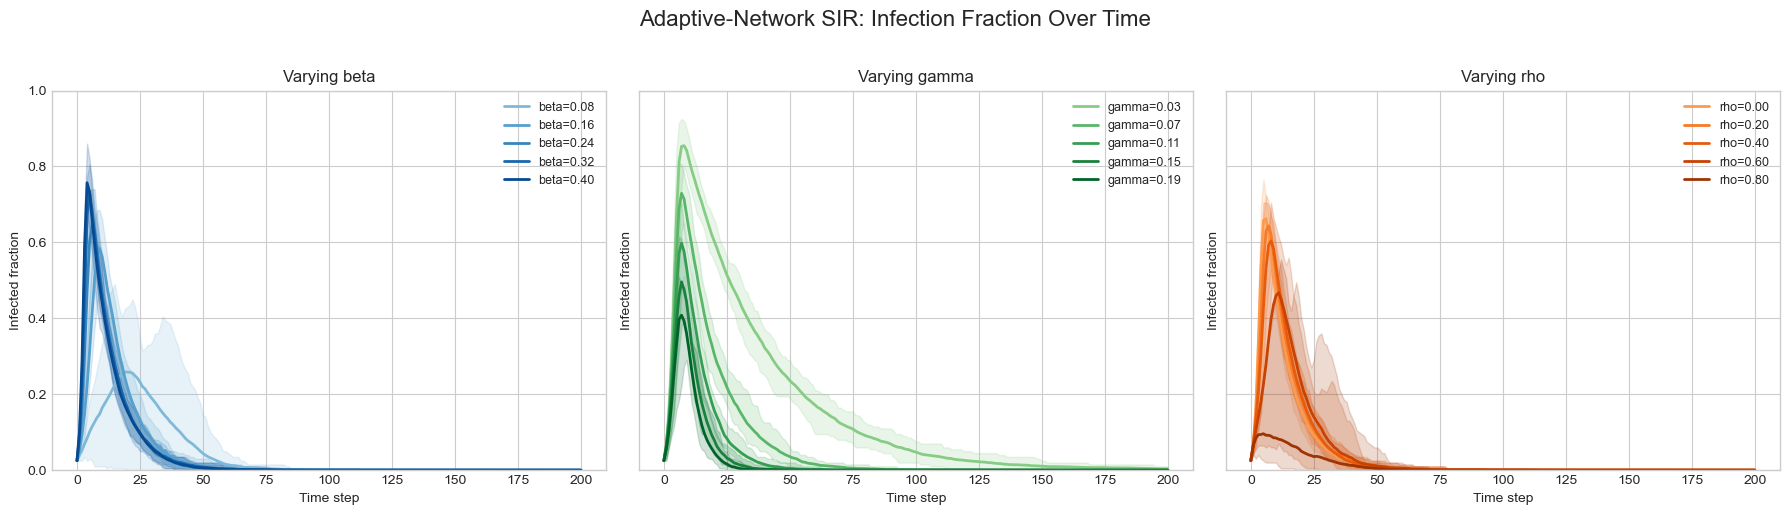

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

beta_colors = plt.cm.Blues(np.linspace(0.45, 0.9, len(results["beta"])))
gamma_colors = plt.cm.Greens(np.linspace(0.45, 0.9, len(results["gamma"])))
rho_colors = plt.cm.Oranges(np.linspace(0.45, 0.9, len(results["rho"])))

plot_parameter_sweep(
    axes[0],
    results["beta"],
    title="Varying beta",
    param_label="beta",
    colors=beta_colors,
)
plot_parameter_sweep(
    axes[1],
    results["gamma"],
    title="Varying gamma",
    param_label="gamma",
    colors=gamma_colors,
)
plot_parameter_sweep(
    axes[2],
    results["rho"],
    title="Varying rho",
    param_label="rho",
    colors=rho_colors,
)

fig.suptitle("Adaptive-Network SIR: Infection Fraction Over Time", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

In [8]:
# Save the figure for later use in the report
figure_path = "parameter_sweep_infection_fraction.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
print(f"Saved figure to {figure_path}")

Saved figure to parameter_sweep_infection_fraction.png


## 6. Three-Level Parameter Combination Grid

The next figure uses low, middle, and high values for each parameter and shows all 27 combinations such as HHH, HHM, HHL, and so on. This is useful for seeing how the three parameters interact when they change together.

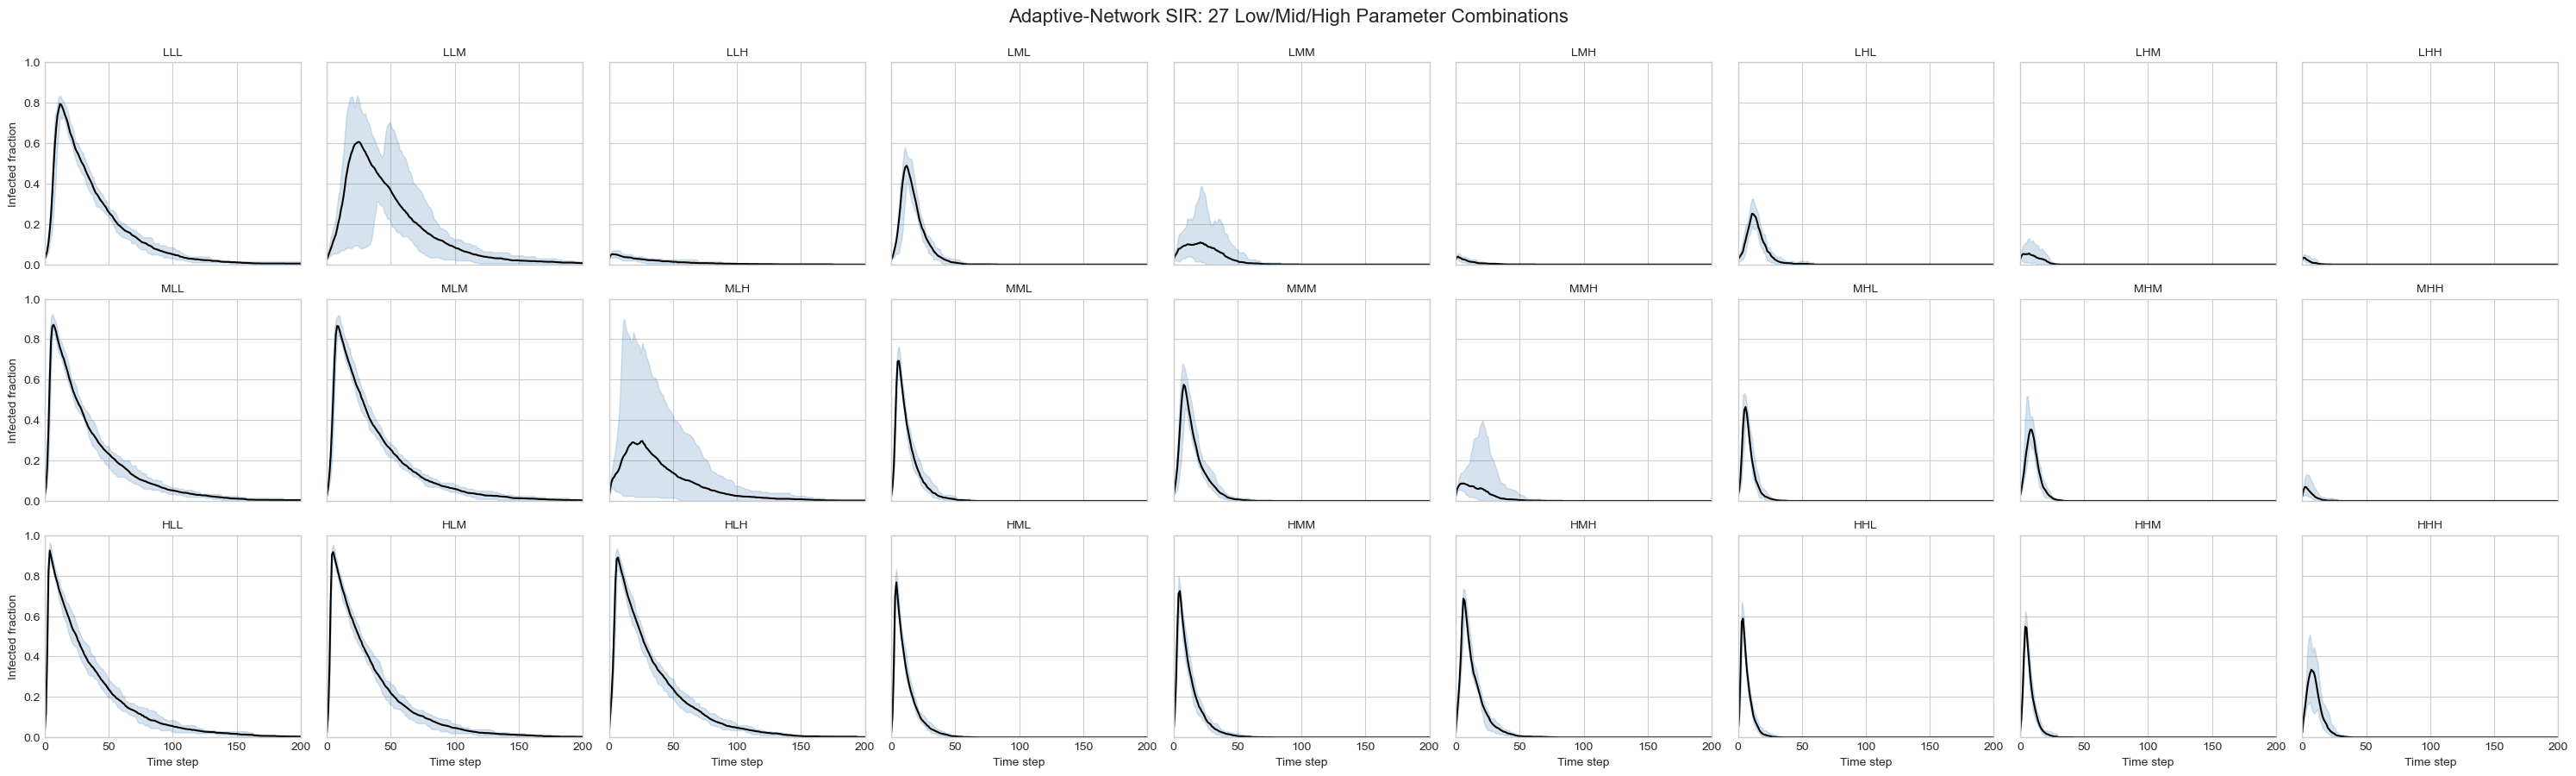

Saved combination grid to parameter_combo_grid_27.png


In [9]:
level_labels = ["L", "M", "H"]
level_values = {
    "beta": [0.08, 0.20, 0.40],
    "gamma": [0.03, 0.10, 0.19],
    "rho": [0.00, 0.40, 0.80],
}

combo_reps = 10
combo_seed_base = 777

combo_results = []
combo_names = []

for beta_label, beta_value in zip(level_labels, level_values["beta"]):
    for gamma_label, gamma_value in zip(level_labels, level_values["gamma"]):
        for rho_label, rho_value in zip(level_labels, level_values["rho"]):
            combo_name = f"{beta_label}{gamma_label}{rho_label}"
            curves = run_replicates(
                beta=beta_value,
                gamma=gamma_value,
                rho=rho_value,
                n_reps=combo_reps,
                seed=combo_seed_base + len(combo_results),
            )
            combo_summary = summarize_curves(curves)
            combo_summary["combo_name"] = combo_name
            combo_summary["beta"] = beta_value
            combo_summary["gamma"] = gamma_value
            combo_summary["rho"] = rho_value
            combo_results.append(combo_summary)
            combo_names.append(combo_name)

fig_combo, axes_combo = plt.subplots(3, 9, figsize=(30, 9), sharex=True, sharey=True)
axes_combo = axes_combo.reshape(3, 9)

for idx, summary in enumerate(combo_results):
    row = idx // 9
    col = idx % 9
    ax = axes_combo[row, col]
    time = summary["time"].to_numpy()
    mean_curve = summary["mean"].to_numpy()
    lower = summary["min"].to_numpy()
    upper = summary["max"].to_numpy()

    ax.plot(time, mean_curve, color="black", linewidth=1.5)
    ax.fill_between(time, lower, upper, color="steelblue", alpha=0.22)
    ax.set_title(summary["combo_name"].iloc[0], fontsize=10)
    ax.set_xlim(0, T)
    ax.set_ylim(0.0, 1.0)

for ax in axes_combo[-1, :]:
    ax.set_xlabel("Time step")
for ax in axes_combo[:, 0]:
    ax.set_ylabel("Infected fraction")

fig_combo.suptitle("Adaptive-Network SIR: 27 Low/Mid/High Parameter Combinations", fontsize=16, y=0.995)
fig_combo.tight_layout()
plt.show()

combo_figure_path = "parameter_combo_grid_27.png"
fig_combo.savefig(combo_figure_path, dpi=200, bbox_inches="tight")
print(f"Saved combination grid to {combo_figure_path}")

## 7. 27-Combination Grid for Rewiring Time Series

Using the same 27 low/mid/high parameter combinations, this figure shows rewiring count over time with mean curve and min-max range shading for each combination.

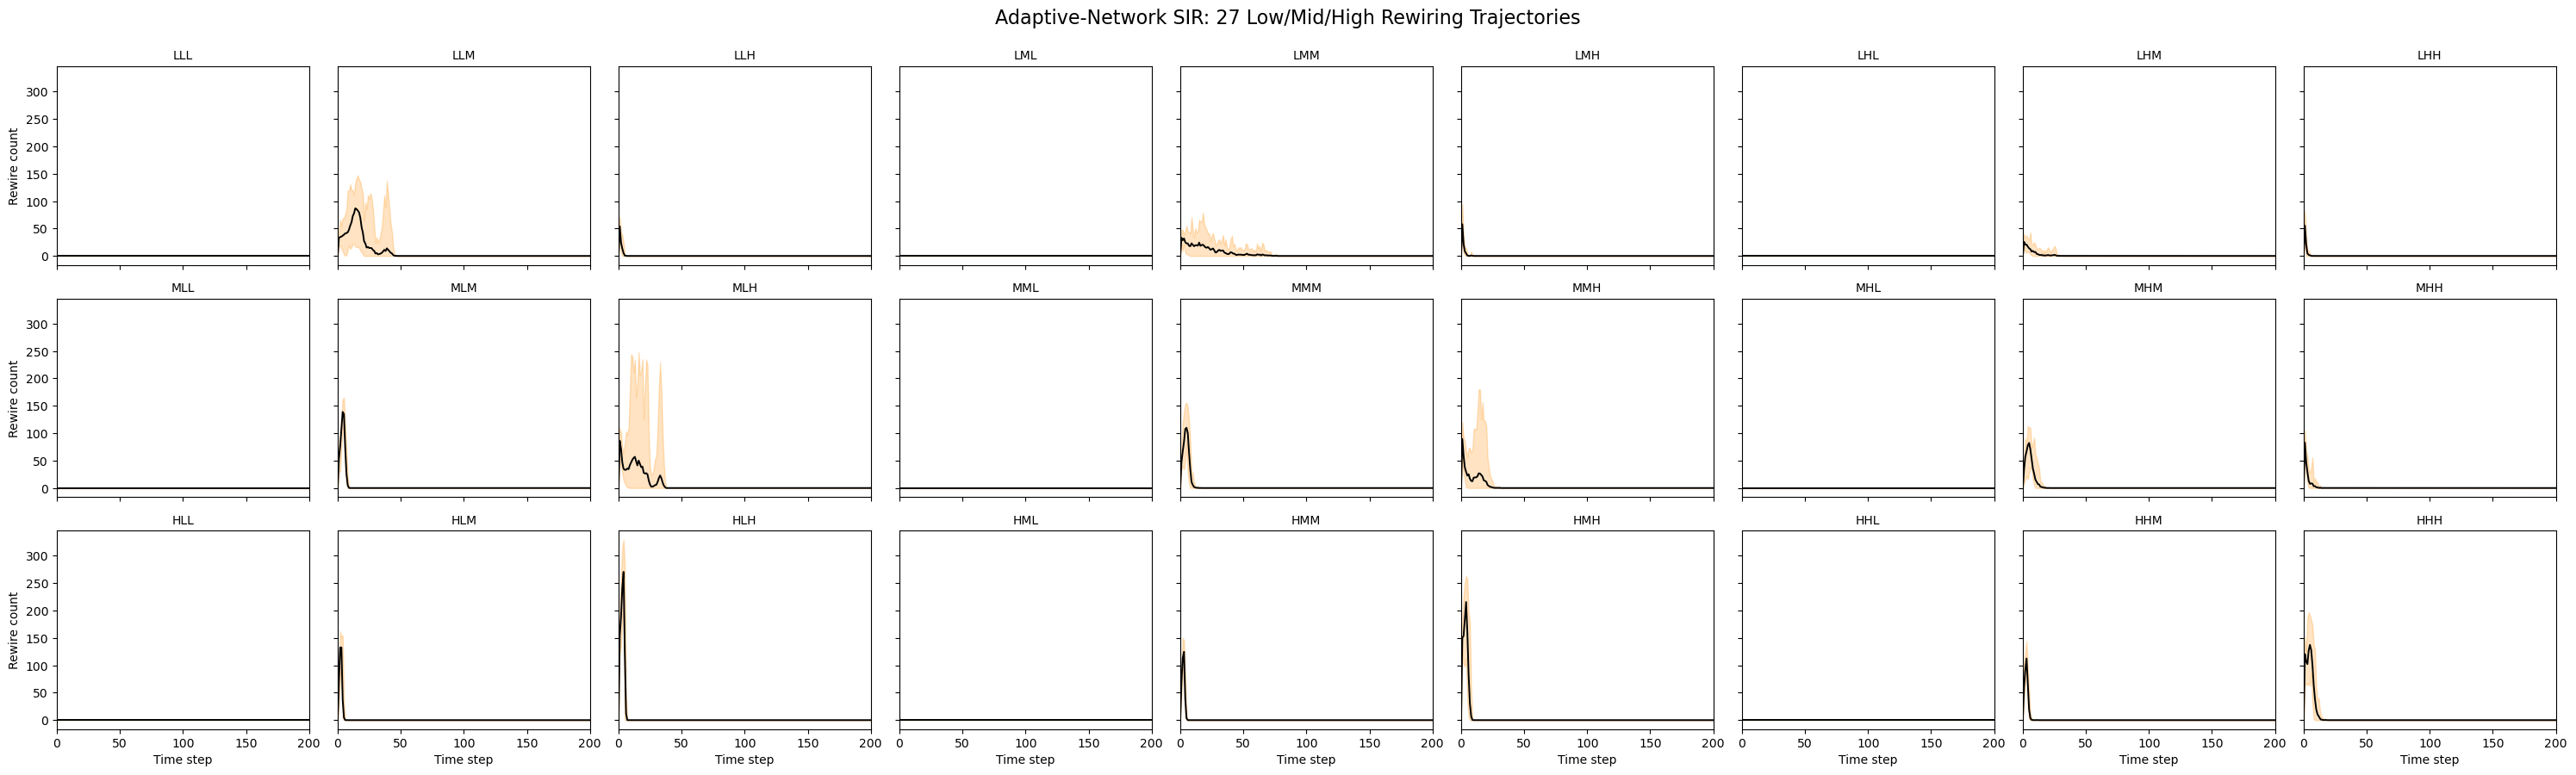

Saved rewiring combination grid to parameter_combo_rewire_grid_27.png


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulator import simulate

if "N" not in globals():
    N = 200
if "p_edge" not in globals():
    p_edge = 0.05
if "n_infected0" not in globals():
    n_infected0 = 5
if "T" not in globals():
    T = 200
if "combo_reps" not in globals():
    combo_reps = 10
if "combo_seed_base" not in globals():
    combo_seed_base = 777

if "level_labels" not in globals():
    level_labels = ["L", "M", "H"]
if "level_values" not in globals():
    level_values = {
        "beta": [0.08, 0.20, 0.40],
        "gamma": [0.03, 0.10, 0.19],
        "rho": [0.00, 0.40, 0.80],
    }

combo_rewire_results = []
combo_degree_results = []

for beta_label, beta_value in zip(level_labels, level_values["beta"]):
    for gamma_label, gamma_value in zip(level_labels, level_values["gamma"]):
        for rho_label, rho_value in zip(level_labels, level_values["rho"]):
            combo_name = f"{beta_label}{gamma_label}{rho_label}"

            rewiring_curves = []
            degree_hists = []
            combo_idx = len(combo_rewire_results)
            rng = np.random.default_rng(combo_seed_base + 10000 + combo_idx)

            for _ in range(combo_reps):
                _, rewiring_ts, degree_hist = simulate(
                    beta=beta_value,
                    gamma=gamma_value,
                    rho=rho_value,
                    N=N,
                    p_edge=p_edge,
                    n_infected0=n_infected0,
                    T=T,
                    rng=rng,
                )
                rewiring_curves.append(rewiring_ts)
                degree_hists.append(degree_hist)

            rewiring_curves = np.asarray(rewiring_curves)
            degree_hists = np.asarray(degree_hists)

            rew_summary = pd.DataFrame(
                {
                    "time": np.arange(T + 1),
                    "mean": rewiring_curves.mean(axis=0),
                    "min": rewiring_curves.min(axis=0),
                    "max": rewiring_curves.max(axis=0),
                    "combo_name": combo_name,
                }
            )
            combo_rewire_results.append(rew_summary)

            deg_summary = pd.DataFrame(
                {
                    "degree": np.arange(31),
                    "mean": degree_hists.mean(axis=0),
                    "min": degree_hists.min(axis=0),
                    "max": degree_hists.max(axis=0),
                    "combo_name": combo_name,
                }
            )
            combo_degree_results.append(deg_summary)

fig_rewire, axes_rewire = plt.subplots(3, 9, figsize=(30, 9), sharex=True, sharey=True)
axes_rewire = axes_rewire.reshape(3, 9)

for idx, summary in enumerate(combo_rewire_results):
    row = idx // 9
    col = idx % 9
    ax = axes_rewire[row, col]

    time = summary["time"].to_numpy()
    mean_curve = summary["mean"].to_numpy()
    lower = summary["min"].to_numpy()
    upper = summary["max"].to_numpy()

    ax.plot(time, mean_curve, color="black", linewidth=1.4)
    ax.fill_between(time, lower, upper, color="darkorange", alpha=0.24)
    ax.set_title(summary["combo_name"].iloc[0], fontsize=10)
    ax.set_xlim(0, T)

for ax in axes_rewire[-1, :]:
    ax.set_xlabel("Time step")
for ax in axes_rewire[:, 0]:
    ax.set_ylabel("Rewire count")

fig_rewire.suptitle("Adaptive-Network SIR: 27 Low/Mid/High Rewiring Trajectories", fontsize=16, y=0.995)
fig_rewire.tight_layout()
plt.show()

rewire_combo_figure_path = "parameter_combo_rewire_grid_27.png"
fig_rewire.savefig(rewire_combo_figure_path, dpi=200, bbox_inches="tight")
print(f"Saved rewiring combination grid to {rewire_combo_figure_path}")

## 8. 27-Combination Grid for Final Degree Histograms

This figure uses the same 27 combinations and shows the final degree distribution with mean count and min-max range shading for each degree bin.

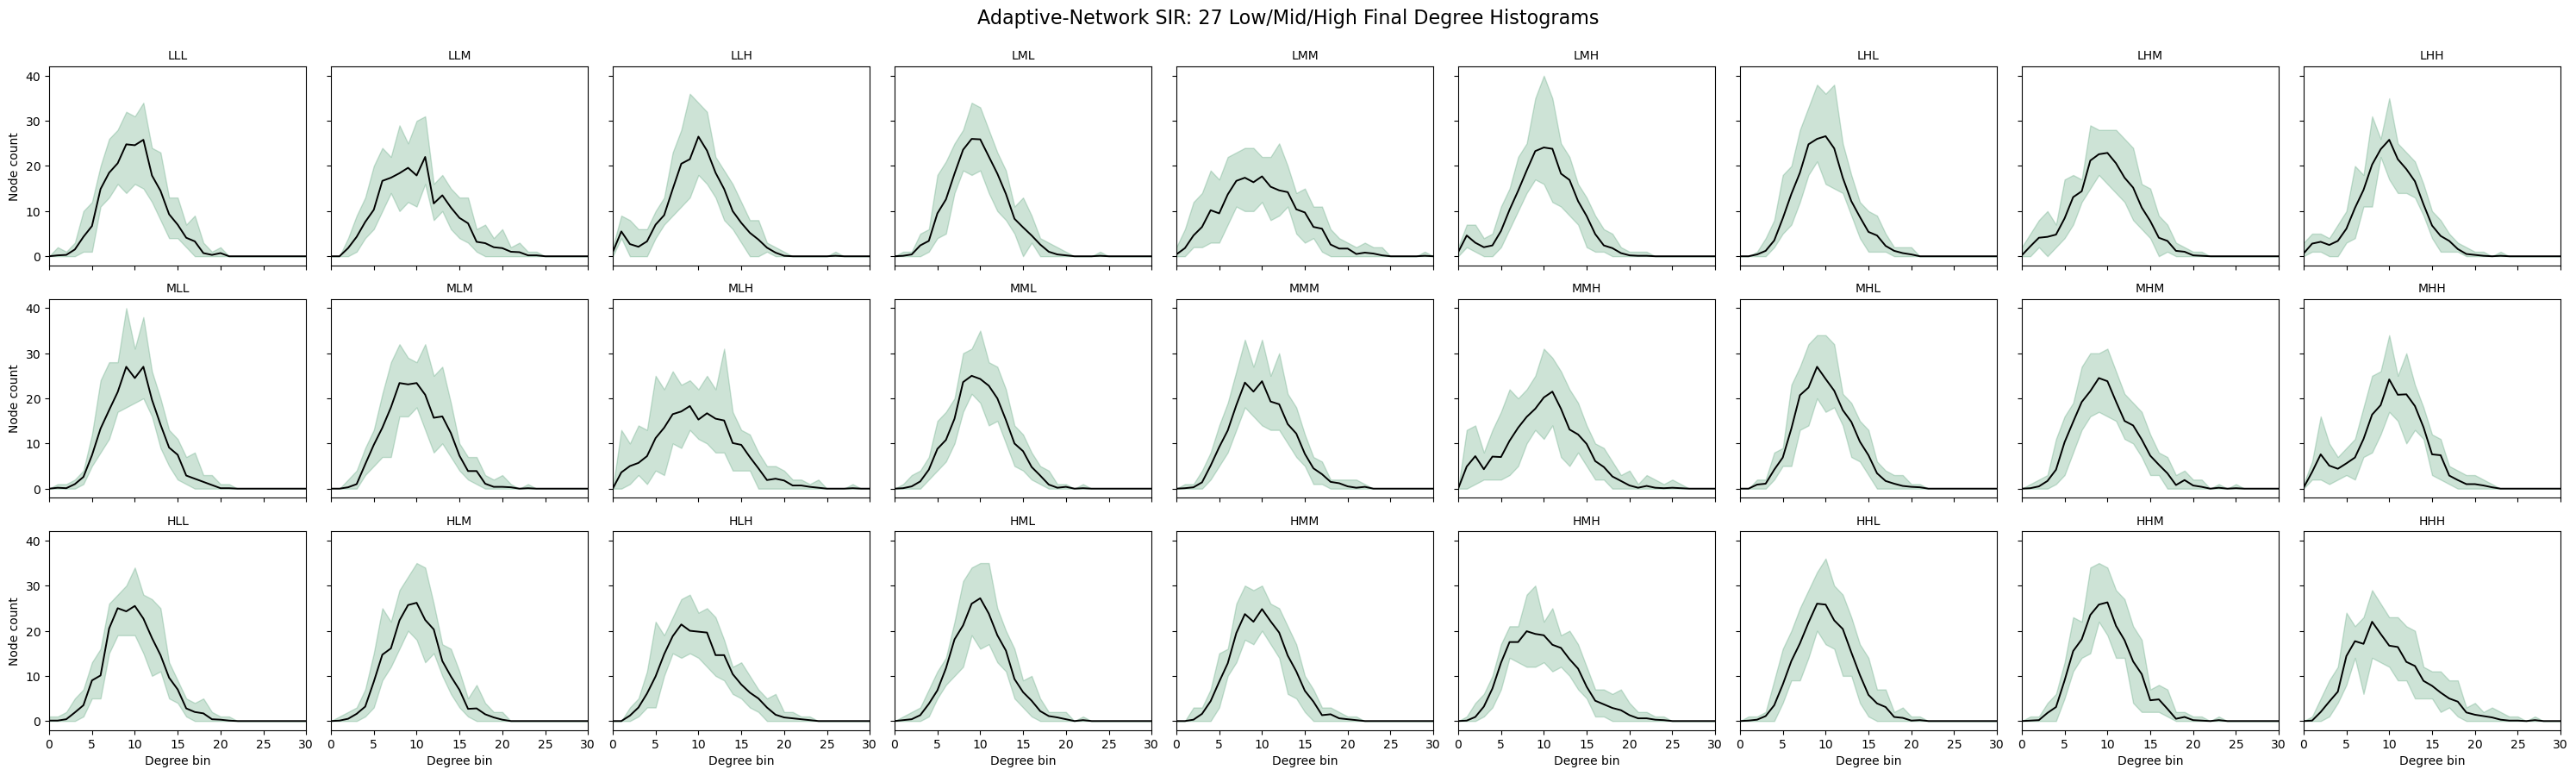

Saved degree-hist combination grid to parameter_combo_degree_grid_27.png


In [4]:
fig_degree, axes_degree = plt.subplots(3, 9, figsize=(30, 9), sharex=True, sharey=True)
axes_degree = axes_degree.reshape(3, 9)

for idx, summary in enumerate(combo_degree_results):
    row = idx // 9
    col = idx % 9
    ax = axes_degree[row, col]

    degree = summary["degree"].to_numpy()
    mean_count = summary["mean"].to_numpy()
    lower = summary["min"].to_numpy()
    upper = summary["max"].to_numpy()

    ax.plot(degree, mean_count, color="black", linewidth=1.4)
    ax.fill_between(degree, lower, upper, color="seagreen", alpha=0.24)
    ax.set_title(summary["combo_name"].iloc[0], fontsize=10)
    ax.set_xlim(0, 30)

for ax in axes_degree[-1, :]:
    ax.set_xlabel("Degree bin")
for ax in axes_degree[:, 0]:
    ax.set_ylabel("Node count")

fig_degree.suptitle("Adaptive-Network SIR: 27 Low/Mid/High Final Degree Histograms", fontsize=16, y=0.995)
fig_degree.tight_layout()
plt.show()

degree_combo_figure_path = "parameter_combo_degree_grid_27.png"
fig_degree.savefig(degree_combo_figure_path, dpi=200, bbox_inches="tight")
print(f"Saved degree-hist combination grid to {degree_combo_figure_path}")

## 9. Refined Summary Statistics from the 27-Combination Diagnostics

This section builds candidate summaries from infection, rewiring, and degree outputs across all 27 low/mid/high combinations. We then select a refined set that:

1. keeps high sensitivity to at least one parameter (beta, gamma, or rho), and
2. avoids redundant summaries by penalizing high pairwise correlation.

This gives a compact summary set with broad information coverage and lower overlap.

In [6]:
import numpy as np
import pandas as pd

from simulator import simulate

if "N" not in globals():
    N = 200
if "p_edge" not in globals():
    p_edge = 0.05
if "n_infected0" not in globals():
    n_infected0 = 5
if "T" not in globals():
    T = 200
if "combo_reps" not in globals():
    combo_reps = 10
if "combo_seed_base" not in globals():
    combo_seed_base = 777
if "level_labels" not in globals():
    level_labels = ["L", "M", "H"]
if "level_values" not in globals():
    level_values = {
        "beta": [0.08, 0.20, 0.40],
        "gamma": [0.03, 0.10, 0.19],
        "rho": [0.00, 0.40, 0.80],
    }


def extinction_time_after_peak(infected_curve, threshold=0.01):
    peak_idx = int(np.argmax(infected_curve))
    after_peak = infected_curve[peak_idx:]
    below = np.where(after_peak <= threshold)[0]
    if len(below) == 0:
        return 1.0
    return float((peak_idx + below[0]) / max(T, 1))


rows = []
for beta_label, beta_value in zip(level_labels, level_values["beta"]):
    for gamma_label, gamma_value in zip(level_labels, level_values["gamma"]):
        for rho_label, rho_value in zip(level_labels, level_values["rho"]):
            combo_name = f"{beta_label}{gamma_label}{rho_label}"
            rng = np.random.default_rng(combo_seed_base + 20000 + len(rows))

            rep_features = []
            for _ in range(combo_reps):
                inf, rew, deg = simulate(
                    beta=beta_value,
                    gamma=gamma_value,
                    rho=rho_value,
                    N=N,
                    p_edge=p_edge,
                    n_infected0=n_infected0,
                    T=T,
                    rng=rng,
                )

                deg_counts = deg.astype(float)
                deg_probs = deg_counts / max(np.sum(deg_counts), 1.0)
                deg_bins = np.arange(len(deg_probs), dtype=float)
                mean_deg = float(np.sum(deg_bins * deg_probs))
                std_deg = float(np.sqrt(np.sum(((deg_bins - mean_deg) ** 2) * deg_probs)))

                rep_features.append(
                    {
                        "infected_peak": float(np.max(inf)),
                        "infected_t_peak": float(np.argmax(inf) / max(T, 1)),
                        "infected_auc": float(np.trapezoid(inf, dx=1.0) / max(T, 1)),
                        "infected_final": float(inf[-1]),
                        "infected_extinction_t": extinction_time_after_peak(inf),
                        "rewire_total": float(np.sum(rew)),
                        "rewire_peak": float(np.max(rew)),
                        "rewire_t_peak": float(np.argmax(rew) / max(T, 1)),
                        "rewire_early": float(np.sum(rew[:21])),
                        "degree_mean": mean_deg,
                        "degree_std": std_deg,
                        "degree_tail_hi": float(np.sum(deg_probs[15:])),
                        "degree_tail_low": float(np.sum(deg_probs[:5])),
                    }
                )

            df_rep = pd.DataFrame(rep_features)
            mean_features = df_rep.mean(axis=0).to_dict()
            row = {
                "combo": combo_name,
                "beta": beta_value,
                "gamma": gamma_value,
                "rho": rho_value,
            }
            row.update(mean_features)
            rows.append(row)

combo_feature_df = pd.DataFrame(rows)
candidate_stats = [
    "infected_peak",
    "infected_t_peak",
    "infected_auc",
    "infected_final",
    "infected_extinction_t",
    "rewire_total",
    "rewire_peak",
    "rewire_t_peak",
    "rewire_early",
    "degree_mean",
    "degree_std",
    "degree_tail_hi",
    "degree_tail_low",
]

param_cols = ["beta", "gamma", "rho"]
assoc = combo_feature_df[candidate_stats + param_cols].corr().loc[candidate_stats, param_cols].abs()
redundancy = combo_feature_df[candidate_stats].corr().abs()

selected = []
remaining = candidate_stats.copy()
max_selected = 9
lambda_overlap = 0.60

while remaining and len(selected) < max_selected:
    scores = {}
    for stat in remaining:
        info = float(assoc.loc[stat].max())
        overlap = float(max([redundancy.loc[stat, s] for s in selected], default=0.0))
        scores[stat] = info - lambda_overlap * overlap
    best = max(scores, key=scores.get)
    selected.append(best)
    remaining.remove(best)

covered_params = set(assoc.loc[selected].idxmax(axis=1).tolist())
for param in param_cols:
    if param not in covered_params:
        best_for_param = assoc[param].idxmax()
        if best_for_param not in selected:
            selected.append(best_for_param)

selected = list(dict.fromkeys(selected))
selected_assoc = assoc.loc[selected]

reason_map = {
    "infected_peak": "Captures epidemic intensity and strong transmission-vs-recovery contrast.",
    "infected_t_peak": "Captures outbreak speed, useful for separating beta from gamma effects.",
    "infected_auc": "Captures overall infection burden over time, robust to local noise.",
    "infected_final": "Captures persistence at horizon and late-stage behavior.",
    "infected_extinction_t": "Captures epidemic duration after peak, strongly linked to recovery and rewiring control.",
    "rewire_total": "Captures total adaptive-response intensity driven by rho and epidemic pressure.",
    "rewire_peak": "Captures maximum behavioral response intensity.",
    "rewire_t_peak": "Captures timing of behavioral response relative to outbreak progression.",
    "rewire_early": "Captures early rewiring response when interventions matter most.",
    "degree_mean": "Captures network-level rewiring impact on average connectivity.",
    "degree_std": "Captures heterogeneity changes in final network structure.",
    "degree_tail_hi": "Captures high-degree tail mass affected by repeated rewiring events.",
    "degree_tail_low": "Captures low-degree mass and possible fragmentation effects.",
}

refined_summary_table = pd.DataFrame(
    {
        "summary_stat": selected,
        "main_parameter_signal": selected_assoc.idxmax(axis=1).values,
        "max_abs_corr_with_params": selected_assoc.max(axis=1).values,
        "why_selected": [reason_map[s] for s in selected],
    }
)

print("Refined summary statistics (selected with information-overlap tradeoff):")
refined_summary_table

Refined summary statistics (selected with information-overlap tradeoff):


,summary_stat,main_parameter_signal,max_abs_corr_with_params,why_selected
0,infected_extinction_t,gamma,0.831456,"Captures epidemic duration after peak, strongl..."
1,degree_std,rho,0.782608,Captures heterogeneity changes in final networ...
2,rewire_peak,rho,0.705031,Captures maximum behavioral response intensity.
3,infected_auc,gamma,0.782661,"Captures overall infection burden over time, r..."
4,degree_tail_low,rho,0.709105,Captures low-degree mass and possible fragment...
5,infected_final,gamma,0.677414,Captures persistence at horizon and late-stage...
6,degree_tail_hi,rho,0.687760,Captures high-degree tail mass affected by rep...
7,infected_peak,beta,0.572855,Captures epidemic intensity and strong transmi...
8,infected_t_peak,beta,0.343083,"Captures outbreak speed, useful for separating..."


### Why These Final Summaries Are a Good Set

The selected summaries are intentionally spread across three domains:

1. infection dynamics (size, timing, duration),
2. rewiring dynamics (strength and timing of adaptive behavior),
3. final topology (degree moments and tail mass).

This combination retains most useful information while limiting overlap because no single domain is allowed to dominate. The correlation-penalized selection keeps redundant statistics out, and the parameter-coverage check ensures beta, gamma, and rho each have at least one strong signal in the final set.

## 10. Save Figures and Export Summary Data

The aggregated summaries can be exported for use in the report or for additional ABC diagnostics. The visualizations help identify which summaries are most sensitive to each parameter.

In [10]:
summary_tables = []
for param_name, sweep_results in results.items():
    for table in sweep_results:
        table = table.copy()
        table["sweep_name"] = param_name
        summary_tables.append(table)

export_summary = pd.concat(summary_tables, ignore_index=True)
export_path = "parameter_sweep_summary.csv"
export_summary.to_csv(export_path, index=False)
print(f"Saved summary data to {export_path}")

Saved summary data to parameter_sweep_summary.csv


## 11. How This Helps Summary Design

These plots show which parts of the trajectory respond to each parameter. That makes it easier to choose ABC summaries that preserve parameter-specific information instead of compressing away the differences between beta, gamma, and rho.